In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from math import sqrt
import xgboost as xgb
from statsmodels.tsa.statespace.sarimax import SARIMAX
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt

In [ ]:
csv_path = "data\jena_climate_2009_2016.csv"
df = pd.read_csv(csv_path)

<>:1: SyntaxWarning: invalid escape sequence '\A'
<>:1: SyntaxWarning: invalid escape sequence '\A'
C:\Users\admin\AppData\Local\Temp\ipykernel_41872\2478020969.py:1: SyntaxWarning: invalid escape sequence '\A'
  csv_path = "D:\Applied_Python_Programming_for_Data_Science\Final_Project\data\jena_climate_2009_2016.csv"


In [ ]:
df['wv (m/s)']=df['wv (m/s)'].replace(-9999.00, 0)
df['max. wv (m/s)']=df['max. wv (m/s)'].replace(-9999.00, 0)

wv = df.pop('wv (m/s)')
max_wv = df.pop('max. wv (m/s)')

wd_rad = df.pop('wd (deg)')*np.pi / 180

df['Wx'] = wv*np.cos(wd_rad)
df['Wy'] = wv*np.sin(wd_rad)

df['max Wx'] = max_wv*np.cos(wd_rad)
df['max Wy'] = max_wv*np.sin(wd_rad)

df = df[5::6]

date_time = pd.to_datetime(df.pop('Date Time'), format='%d.%m.%Y %H:%M:%S')

df = df.reset_index()
df = df.drop(columns=['index'])

date_time = date_time.reset_index()
date_time = date_time.drop(columns=['index'])

In [4]:
df.shape

(70091, 15)

In [5]:
date_time.shape

(70091, 1)

In [6]:
target_col = 'T (degC)'
feature_cols = df.columns.drop(target_col)

In [ ]:
split_idx = int(len(df) * 0.7)
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

y_train = train_df[target_col]
y_test = test_df[target_col]
X_train = train_df[feature_cols]
X_test = test_df[feature_cols]

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
def create_sequences(X, y, seq_length=24):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i+seq_length])
    return np.array(X_seq), np.array(y_seq)

seq_length = 24
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train.values, seq_length)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test.values, seq_length)

In [10]:
lstm_model_1 = Sequential([
    LSTM(64, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dense(1)
])
lstm_model_1.compile(optimizer='adam', loss='mse')
lstm_model_1.fit(X_train_seq, y_train_seq, epochs=10, batch_size=64, validation_split=0.1, verbose=2)

y_pred_lstm_1 = lstm_model_1.predict(X_test_seq)
rmse_lstm_1 = sqrt(mean_squared_error(y_test_seq, y_pred_lstm_1))

rmse_lstm_1

Epoch 1/10


c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


690/690 - 16s - 23ms/step - loss: 12.6899 - val_loss: 1.4477
Epoch 2/10
690/690 - 15s - 22ms/step - loss: 0.9908 - val_loss: 0.7532
Epoch 3/10
690/690 - 15s - 21ms/step - loss: 0.6443 - val_loss: 0.6518
Epoch 4/10
690/690 - 16s - 23ms/step - loss: 0.5580 - val_loss: 0.5897
Epoch 5/10
690/690 - 16s - 23ms/step - loss: 0.5327 - val_loss: 0.5751
Epoch 6/10
690/690 - 15s - 22ms/step - loss: 0.5115 - val_loss: 0.5723
Epoch 7/10
690/690 - 15s - 22ms/step - loss: 0.5016 - val_loss: 0.5647
Epoch 8/10
690/690 - 15s - 21ms/step - loss: 0.4990 - val_loss: 0.5707
Epoch 9/10
690/690 - 16s - 23ms/step - loss: 0.4902 - val_loss: 0.5653
Epoch 10/10
690/690 - 16s - 23ms/step - loss: 0.4859 - val_loss: 0.5535
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step


0.6855610321974578

In [11]:
lstm_model_2 = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dropout(0.2),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(1)
])
lstm_model_2.compile(optimizer='adam', loss='mse')
lstm_model_2.fit(X_train_seq, y_train_seq, epochs=10, batch_size=64, validation_split=0.1, verbose=2)

y_pred_lstm_2 = lstm_model_2.predict(X_test_seq)
rmse_lstm_2 = sqrt(mean_squared_error(y_test_seq, y_pred_lstm_2))

rmse_lstm_2

Epoch 1/10


c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


690/690 - 42s - 60ms/step - loss: 7.8580 - val_loss: 0.7232
Epoch 2/10
690/690 - 40s - 58ms/step - loss: 0.7498 - val_loss: 0.6581
Epoch 3/10
690/690 - 40s - 58ms/step - loss: 0.6676 - val_loss: 0.8513
Epoch 4/10
690/690 - 41s - 60ms/step - loss: 0.6348 - val_loss: 0.5955
Epoch 5/10
690/690 - 40s - 57ms/step - loss: 0.6278 - val_loss: 0.7061
Epoch 6/10
690/690 - 43s - 63ms/step - loss: 0.6083 - val_loss: 0.5690
Epoch 7/10
690/690 - 40s - 58ms/step - loss: 0.5995 - val_loss: 0.5790
Epoch 8/10
690/690 - 43s - 63ms/step - loss: 0.5820 - val_loss: 0.6434
Epoch 9/10
690/690 - 44s - 64ms/step - loss: 0.5783 - val_loss: 0.5857
Epoch 10/10
690/690 - 43s - 62ms/step - loss: 0.5712 - val_loss: 0.5584
657/657 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step


0.7053454820289518

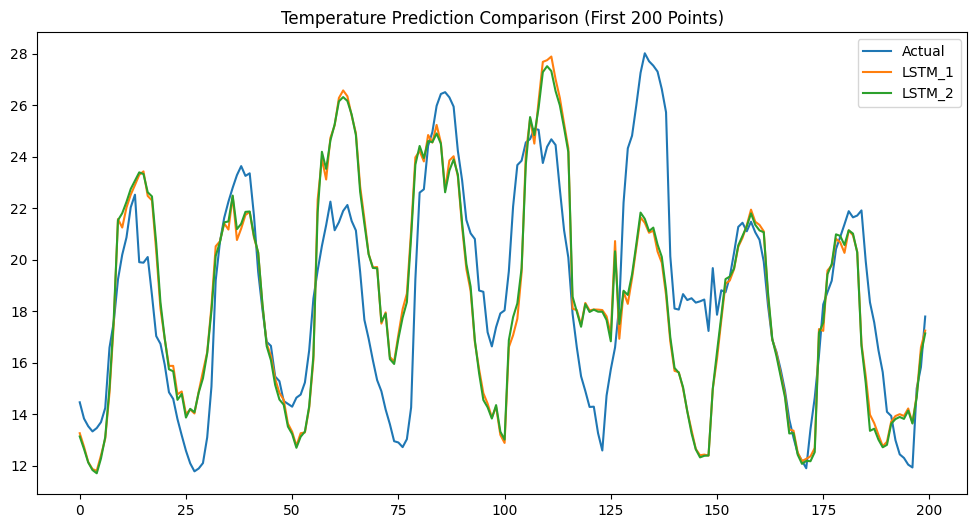

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values[:200], label='Actual')
plt.plot(y_pred_lstm_1[:200], label='LSTM_1')
plt.plot(y_pred_lstm_2[:200], label='LSTM_2')
plt.legend()
plt.title('Temperature Prediction Comparison (First 200 Points)')
plt.show()

In [ ]:
lstm_model_3 = Sequential([
    LSTM(32, return_sequences=True, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dense(1)
])
lstm_model_3.compile(optimizer='adam', loss='mse')
lstm_model_3.fit(X_train_seq, y_train_seq, epochs=10, batch_size=64, validation_split=0.1, verbose=2)

y_pred_lstm_3 = lstm_model_3.predict(X_test_seq)
rmse_lstm_3 = sqrt(mean_squared_error(y_test_seq, y_pred_lstm_3))

rmse_lstm_3